# Fire Detection Model using YOLOv8
From the publicly available dataset (https://universe.roboflow.com/aj-garcia-736tc/fire-dataset-for-yolov8)

In [2]:
import os
import shutil
import re
import matplotlib.pyplot as plt
import cv2

from roboflow import Roboflow
from dotenv import load_dotenv
from pathlib import Path
from ultralytics import YOLO

# Download the dataset if it hasnt been downloaded yet
if not os.path.exists('./Fire-Dataset-for-YOLOv8-10'):
    load_dotenv(Path('.env'))
    rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
    project = rf.workspace("aj-garcia-736tc").project("fire-dataset-for-yolov8")
    version = project.version(10)
    dataset = version.download("yolov8")
                

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [3]:
train_path = Path("./Fire-Dataset-for-YOLOv8-10/train/images")
train_size = len(os.listdir(train_path))

val_path = Path("./Fire-Dataset-for-YOLOv8-10/valid/images")
val_size = len(os.listdir(val_path))

print(f"Train images size: {train_size}, Val images size: {val_size}")

Train images size: 3196, Val images size: 800


Text(0.5, 1.0, 'Train/ Val Distribution')

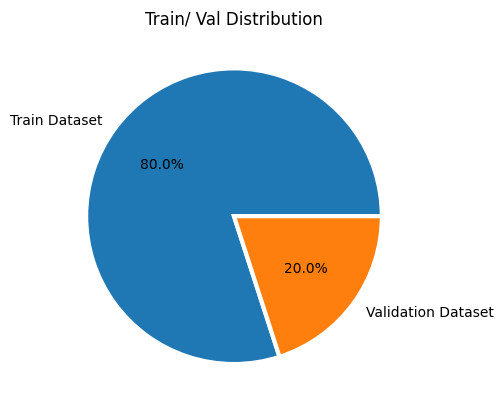

In [4]:
names = ["Train Dataset", "Validation Dataset"]
values = [train_size, val_size]

# Visualize the percentage of the distributed datasets
plt.pie(x=values, labels=names, autopct='%.1f%%', wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'})
plt.title("Train/ Val Distribution")

In [4]:
%cd ~/Documents/Projects/UNI544-SymbIoT-Prototype

/home/adhy/Documents/Projects/UNI544-SymbIoT-Prototype


This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.


In [5]:
!yolo task=detect mode=train model=Weights/yolov8n.pt data=Fire-Dataset-for-YOLOv8-10/data.yaml \
    epochs=150 imgsz=640 batch=32 save=True augment=True patience=20 \
    degrees=3 translate=0.1 scale=0.3 flipud=0.1 fliplr=0.3 optimizer="auto" cos_lr=False


/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "
New https://pypi.org/project/ultralytics/8.3.96 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.91 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3806MiB)
engine/trainer: task=detect, mode=train, model=Models/yolov8n.pt, data=Fire-Dataset-for-YOLOv8-10/data.yaml, epochs=150, time=None, patience=20, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train41, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, sav

In [4]:
runs_dir = './runs'
# Get the latest results and evaluate them
if os.path.exists(runs_dir):
    all_dirs = os.listdir(os.path.join(runs_dir, 'detect'))
    train_dirs = [dir for dir in all_dirs if re.match("train", dir)]
    last_train = sorted(train_dirs, key=lambda x: (len(x), x))[-1]

    last_weight_path = os.path.join(runs_dir, 'detect', last_train, 'weights/best.pt')

    model = YOLO(last_weight_path)
    metrics = model.val()
    print(metrics.box.map50)

Ultralytics 8.3.91 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3806MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /home/adhy/Documents/Projects/UNI544-SymbIoT-Prototype/datasets/Fire-Dataset-for-YOLOv8-10/valid/labels.cache... 800 images, 55 backgrounds, 0 corrupt: 100%|██████████| 800/800 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:04<00:00, 11.59it/s]


                   all        800       1015      0.608      0.461       0.45      0.201
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/val10
0.4497681805010552


In [5]:
# Current best model
best_model_path = 'runs/detect/train38/weights/best.pt'
model = YOLO(best_model_path)
metrics = model.val()
print(metrics.box.map50)

# Get the val directory and sort them
val_dirs = [dir for dir in all_dirs if re.match("val", dir)]
last_val = sorted(val_dirs, key=lambda x: (len(x), x))[-1]

last_val_path = os.path.join(runs_dir, 'detect', last_val)
last_val_files = os.listdir(last_val_path)

# Get metrics (F1, P, R , PR)
def get_metric_plots():
    metrics_files = [file for file in last_val_files if not re.match("val", file) and not re.match("confusion", file)]
    
    rows = 2
    cols = 2
    fig  = plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics_files):
        img = cv2.cvtColor(cv2.imread(os.path.join(last_val_path, metric)), cv2.COLOR_BGR2RGB)

        fig.add_subplot(rows, cols, i+1)

        plt.imshow(img)
        plt.axis("off")
        plt.title(metric)

def get_confusion_matrix():
    cm_files = [file for file in last_val_files if re.match("confusion", file)]
    
    rows = 1
    cols = 2
    fig  = plt.figure(figsize=(20, 10))

    for i, cm in enumerate(cm_files):
        img = cv2.cvtColor(cv2.imread(os.path.join(last_val_path, cm)), cv2.COLOR_BGR2RGB)

        fig.add_subplot(rows, cols, i+1)

        plt.imshow(img)
        plt.axis("off")
        plt.title(cm)

def get_val_img_pred_labels():
    val_img_files = [file for file in last_val_files if re.match("val", file)]
    
    rows = 2
    cols = 3
    fig  = plt.figure(figsize=(20, 10))

    for i, val_img in enumerate(val_img_files):
        img = cv2.cvtColor(cv2.imread(os.path.join(last_val_path, val_img)), cv2.COLOR_BGR2RGB)

        fig.add_subplot(rows, cols, i+1)

        plt.imshow(img)
        plt.axis("off")
        plt.title(val_img)

Ultralytics 8.3.91 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3806MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /home/adhy/Documents/Projects/UNI544-SymbIoT-Prototype/datasets/Fire-Dataset-for-YOLOv8-10/valid/labels.cache... 800 images, 55 backgrounds, 0 corrupt: 100%|██████████| 800/800 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 50/50 [00:10<00:00,  4.86it/s]


                   all        800       1015      0.619      0.507      0.505      0.203
Speed: 0.5ms preprocess, 9.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val11
0.5052927621600687


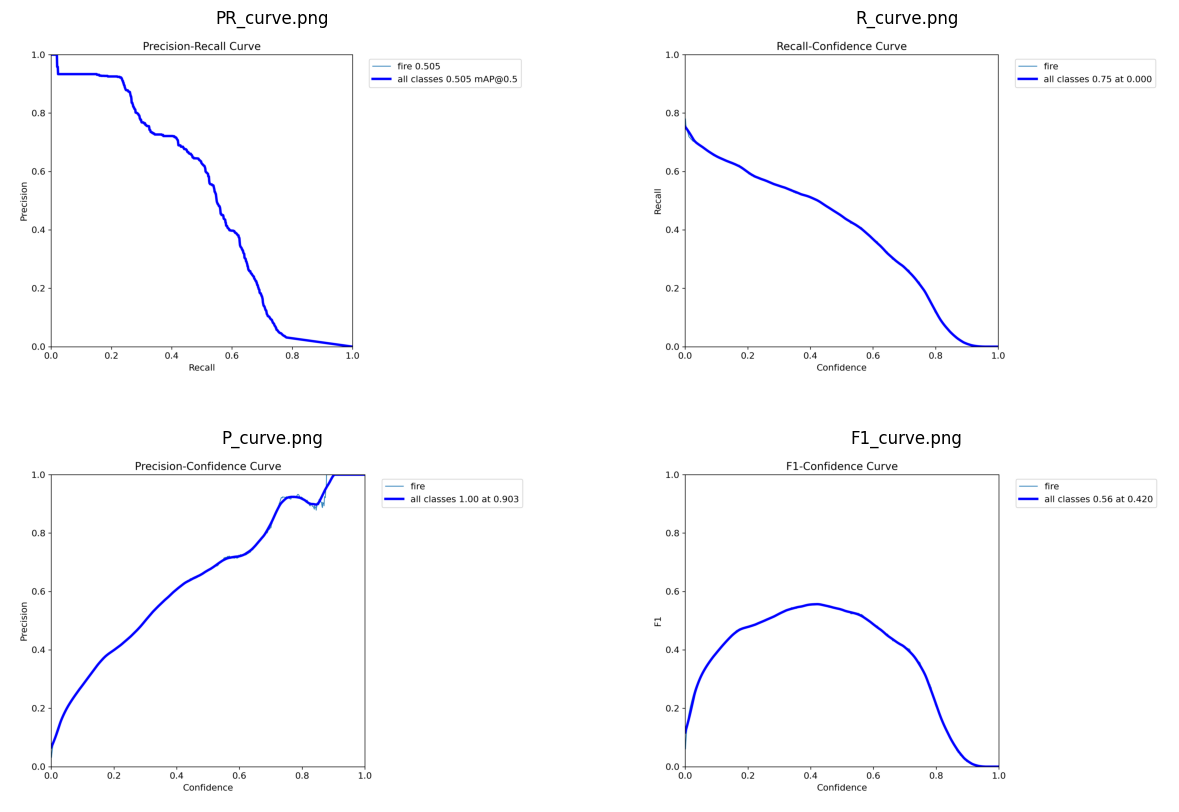

In [36]:
get_metric_plots()

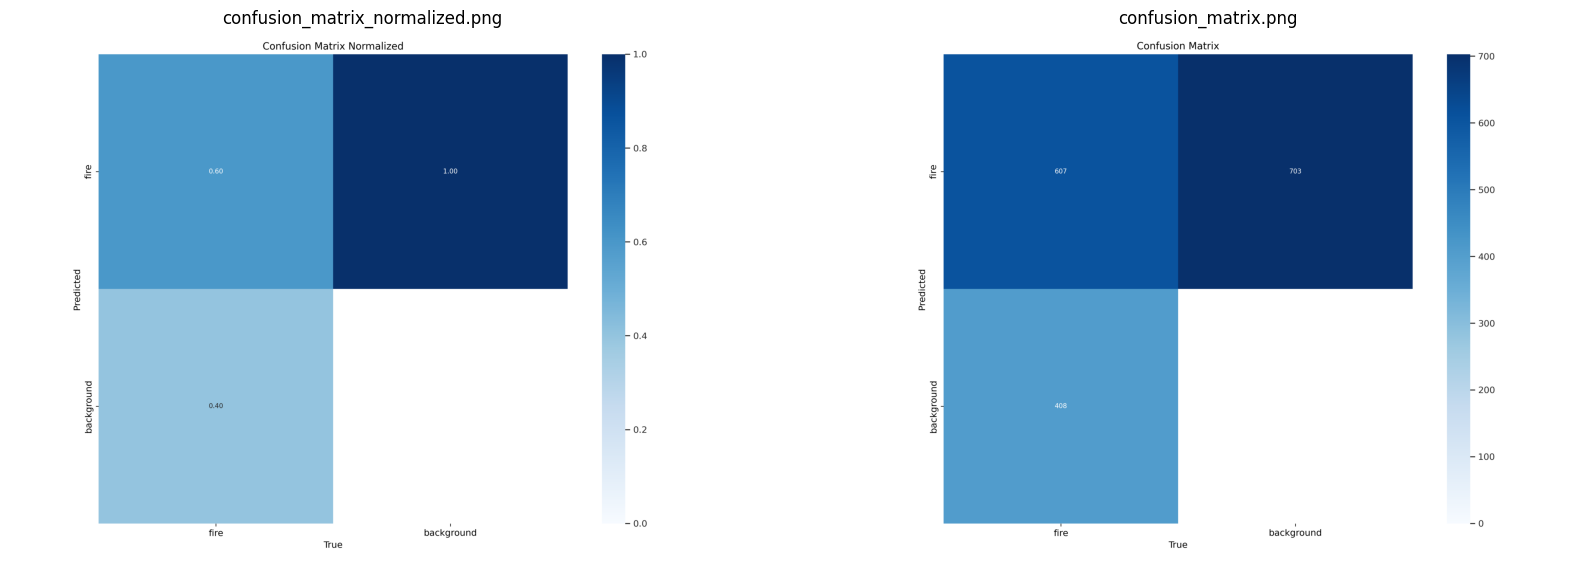

In [37]:
get_confusion_matrix()

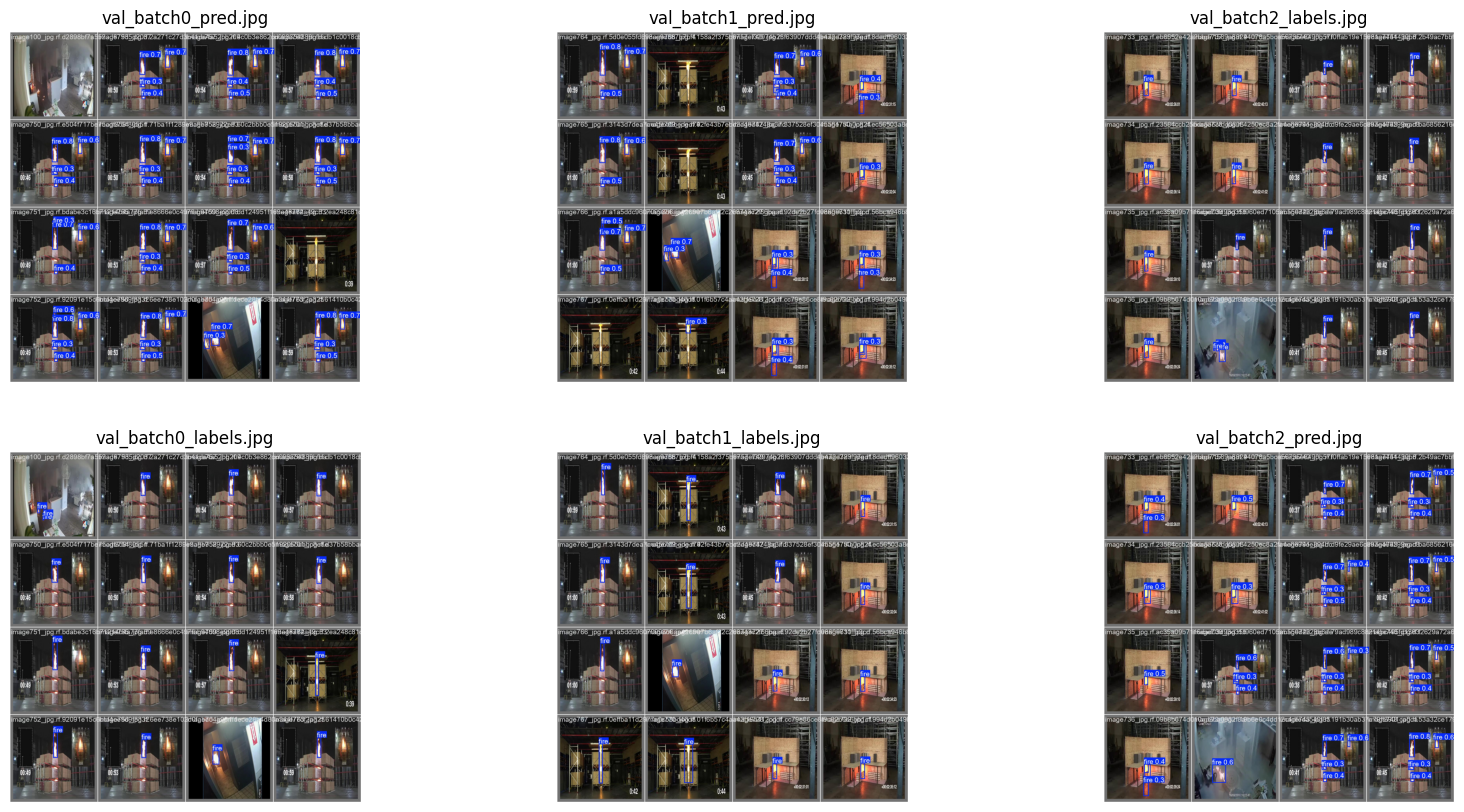

In [38]:
get_val_img_pred_labels()

In [6]:
# Copy best result into output folder
shutil.copy(best_model_path, './Output/yolo_model.pt')

'./Output/yolo_model.pt'